# NB04 — Confound-Breaker: Is the Coupling Competence or Dataset?

**The open question (from NB03):** the competence–calibration coupling is significant across
16 points (r=−0.78, p=0.0004), BUT DF40's 8 generators cluster flat (low ECE_cal across their
AUC range). The correlation is carried by the FF++ low-competence tail. So:

> Is the coupling driven by **competence**, or by a **dataset effect** (FF++ calibrates worse
> than DF40, and FF++ happens to span more competence)?

**The test:** force LOW competence on DF40 by scoring with a **mismatched checkpoint**
(reenactment-trained `train_on_fr` on DF40's swap/synthesis methods → should crater AUC).
Then calibrate and check where those low-AUC DF40 points land.

**Decision rule:**
- Low-AUC DF40 points show **HIGH ECE_cal** (land top-left with FF++ low-competence points)
  → coupling holds WITHIN DF40 → **confound broken, finding robust.** ✓
- Low-AUC DF40 points stay **LOW ECE_cal** (bottom, despite low AUC)
  → it's a dataset effect → finding narrows to FF++/specific conditions.

Reuses: `src/inference.py`, `src/calibrate_scores.py`, the DF40 unzip+remap flow.
The path-hash fix in inference.py means the FR checkpoint won't collide with the FS local copy.


## Cell 1 — Mount, paths, deps, git creds

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
import os, sys, glob, subprocess
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
PARENT = "/content/drive/MyDrive/CDTS_Research"
DFB = f"{REPO}/external/DeepfakeBench"
for f in [".gitconfig",".git-credentials"]:
    if os.path.exists(f"{PARENT}/{f}"): subprocess.run(f'cp "{PARENT}/{f}" /root/{f}', shell=True)
subprocess.run("git config --global credential.helper store", shell=True)
# deps for DeepfakeBench inference (fresh runtime)
print("installing deps...")
subprocess.run("pip -q install efficientnet_pytorch timm einops kornia simplejson", shell=True)
print("mount:", os.path.isdir(REPO))
print("FR checkpoint:", os.path.exists(f"{REPO}/weights/train_on_fr/xception.pth"))
print("DF40 core zips:", [os.path.basename(z) for z in glob.glob(f"{REPO}/data/df40_core/test/*.zip")])
print("existing FS DF40 scores:", len(glob.glob(f"{REPO}/reports/scores/xceptionFS_df40_*.parquet")))

Mounted at /content/drive
installing deps...
mount: True
FR checkpoint: True
DF40 core zips: ['facevid2vid.zip', 'fomm.zip', 'inswap.zip', 'simswap.zip', 'blendface.zip', 'styleclip.zip', 'StyleGAN2.zip', 'ddim.zip', 'sd2.1.zip']
existing FS DF40 scores: 8


## Cell 2 — Load the MISMATCHED (reenactment-trained) checkpoint

`train_on_fr/xception.pth` — trained on face-reenactment. Its weakness is swap/synthesis,
so it should score DF40's FS (simswap, blendface) and EFS (StyleGAN2, sd2.1) methods POORLY.
That deliberate mismatch gives us the low-competence DF40 points we need.


In [2]:
import sys, importlib.util, torch, hashlib
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
DFB = f"{REPO}/external/DeepfakeBench"

# inference env: DeepfakeBench metrics package FIRST
for k in list(sys.modules.keys()):
    if k.startswith("detectors") or k.startswith("networks") or k=="metrics" or k.startswith("metrics.") or k=="inference":
        del sys.modules[k]
sys.path = [p for p in sys.path if p not in (f"{DFB}/training", f"{REPO}/src", DFB)]
sys.path.insert(0, DFB); sys.path.insert(0, f"{DFB}/training"); sys.path.append(f"{REPO}/src")

spec = importlib.util.spec_from_file_location("inference", f"{REPO}/src/inference.py")
inference = importlib.util.module_from_spec(spec); sys.modules["inference"]=inference
spec.loader.exec_module(inference)

fr_path = f"{REPO}/weights/train_on_fr/xception.pth"
model, device, info = inference.load_detector(dfb_root=DFB, backbone_name="xception", ckpt_path=fr_path)
print("FR xception load:", info, "device:", device)

# VERIFY it's actually FR (not a stale FS copy — the path-hash fix should ensure this)
tag = hashlib.md5(fr_path.encode()).hexdigest()[:8]
fr_sd = torch.load(f"/content/_ckpt_xception_{tag}.pth", map_location="cpu")
mp = dict(model.named_parameters()); mk = [k for k in mp if 'conv1' in k][0]
print("model matches FR conv1:", torch.allclose(mp[mk].cpu(), fr_sd["module.backbone.conv1.weight"]))

FR xception load: {'missing': 0, 'unexpected': 0} device: cuda
model matches FR conv1: True


## Cell 3 — Score DF40 methods with the FR checkpoint

Pick methods the FR model should fail on: **simswap, blendface** (FS) + **StyleGAN2, sd2.1**
(EFS). Unzip → manifest (cdf JSON) → remap fakes to local + reals to cropped Celeb-DF → score.
Same flow as NB03, just the mismatched checkpoint.


In [3]:
import os, glob, json, zipfile, shutil
import pandas as pd, importlib.util, sys
from sklearn.metrics import roc_auc_score
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"

# data_prep
spec = importlib.util.spec_from_file_location("data_prep", f"{REPO}/src/data_prep.py")
data_prep = importlib.util.module_from_spec(spec); sys.modules["data_prep"]=data_prep
spec.loader.exec_module(data_prep)

# real index (Celeb-DF crop), build once
CDF_REAL = f"{REPO}/data/frames/Celeb-DF-v2"
real_index = {"/".join(fp.split("/")[-2:]): fp
              for fp in glob.glob(f"{CDF_REAL}/**/frames/**/*.png", recursive=True)}
print(f"real index: {len(real_index)} frames\n")

# methods FR should fail on (FS swap + EFS synthesis)
methods = ["simswap", "blendface", "StyleGAN2", "sd2.1"]

for method in methods:
    print(f"=== {method} (FR checkpoint) ===")
    zp = f"{REPO}/data/df40_core/test/{method}.zip"
    jpath = f"{REPO}/data/df40/dataset_json/{method}_cdf.json"
    if not (os.path.exists(zp) and os.path.exists(jpath)):
        print("  missing zip/json, skip"); continue
    fdir = f"/content/df40fr_{method}"
    if not os.path.isdir(fdir):
        os.makedirs(fdir, exist_ok=True)
        with zipfile.ZipFile(zp) as z: z.extractall(fdir)
    fake_index = {"/".join(fp.split("/")[-2:]): fp for fp in glob.glob(f"{fdir}/**/*.png", recursive=True)}
    df = data_prep.build_manifest_from_json(f"{method}_cdf", jpath, frames_root=None)
    def remap(row):
        key = "/".join(row["frame_path"].split("/")[-2:])
        return fake_index.get(key) if row["label"]==1 else real_index.get(key)
    df["frame_path"] = df.apply(remap, axis=1)
    df = df[df["frame_path"].notna()].reset_index(drop=True)
    if df['label'].nunique() < 2:
        print("  one label only, skip"); shutil.rmtree(fdir, ignore_errors=True); continue
    scores = inference.score_manifest(model, device, df, batch_size=64, verbose=False)
    scores.to_parquet(f"{REPO}/reports/scores/xceptionFR_df40_{method}.parquet", index=False)
    auc = roc_auc_score(scores.label, scores.prob_fake)
    print(f"  AUC = {auc:.4f}  (n={len(scores)})  <- want LOW (mismatch)")
    shutil.rmtree(fdir, ignore_errors=True)
print("\nPass done. FR-on-DF40 scores saved.")

real index: 16420 frames

=== simswap (FR checkpoint) ===
  AUC = 0.3793  (n=25942)  <- want LOW (mismatch)
=== blendface (FR checkpoint) ===
  AUC = 0.4640  (n=25943)  <- want LOW (mismatch)
=== StyleGAN2 (FR checkpoint) ===
  AUC = 0.2624  (n=33794)  <- want LOW (mismatch)
=== sd2.1 (FR checkpoint) ===
  AUC = 0.3343  (n=33794)  <- want LOW (mismatch)

Pass done. FR-on-DF40 scores saved.


## Cell 4 — Calibrate the FR-on-DF40 scores + THE DECISION

For each low-AUC DF40 point: does ECE_cal go HIGH (coupling within DF40) or stay LOW (dataset effect)?
We append these points to the combined pool and re-check the within-DF40 correlation.


In [4]:
import sys, importlib.util, os, glob
import numpy as np, pandas as pd
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"

# calibration env (src first)
for k in list(sys.modules.keys()):
    if k=="metrics" or k.startswith("metrics.") or k=="calibration":
        del sys.modules[k]
sys.path = [p for p in sys.path if "DeepfakeBench" not in p]
if f"{REPO}/src" in sys.path: sys.path.remove(f"{REPO}/src")
sys.path.insert(0, f"{REPO}/src")
import calibration as cal, metrics as met

rows = []
for f in sorted(glob.glob(f"{REPO}/reports/scores/xceptionFR_df40_*.parquet")):
    method = os.path.basename(f).replace("xceptionFR_df40_","").replace(".parquet","")
    s = pd.read_parquet(f)
    p = s.prob_fake.values.astype(float); y = s.label.values.astype(int)
    g = s.identity_id.values if "identity_id" in s.columns else None
    ci, ti, _ = cal.leakage_safe_split(y, groups=g, calib_frac=0.5, seed=42)
    p_cal, _ = cal.fit_predict("hybrid", p[ci], y[ci], p[ti], switch_threshold_n=1000)
    ece_raw = met.ece(p[ti], y[ti], n_bins=15, scheme="equal_mass")
    ece_cal = met.ece(p_cal, y[ti], n_bins=15, scheme="equal_mass")
    auc = met.roc_auc(p[ti], y[ti]) if hasattr(met,"roc_auc") else float("nan")
    rows.append({"method":f"df40FR_{method}","checkpoint":"train_on_fr","source":"DF40_mismatch",
                 "AUC":auc,"ECE_raw":ece_raw,"ECE_cal":ece_cal})
    print(f"  {method:12s}  AUC={auc:.4f}  ECE_raw={ece_raw:.4f}  ECE_cal={ece_cal:.4f}")

fr_pts = pd.DataFrame(rows)
fr_pts.to_csv(f"{REPO}/reports/calibration/coupling_df40_FRmismatch.csv", index=False)

print("\n=== THE DECISION ===")
print("FR-on-DF40 points (these should be LOW AUC by design):")
print(fr_pts[["method","AUC","ECE_cal"]].to_string(index=False))
hi = (fr_pts.ECE_cal > 0.12).sum()  # FF++ low-competence had ECE_cal 0.16-0.34
print(f"\n{hi}/{len(fr_pts)} low-AUC DF40 points have HIGH ECE_cal (>0.12)")
if hi >= len(fr_pts)*0.5:
    print(">>> HIGH ECE at low AUC within DF40 -> COUPLING HOLDS, confound BROKEN. Finding robust.")
else:
    print(">>> LOW ECE despite low AUC -> looks like a DATASET effect. Finding narrows.")

  StyleGAN2     AUC=0.2561  ECE_raw=0.5040  ECE_cal=0.2677
  blendface     AUC=0.4565  ECE_raw=0.2544  ECE_cal=0.2481
  sd2.1         AUC=0.3291  ECE_raw=0.4114  ECE_cal=0.2677
  simswap       AUC=0.3629  ECE_raw=0.3309  ECE_cal=0.3012

=== THE DECISION ===
FR-on-DF40 points (these should be LOW AUC by design):
          method      AUC  ECE_cal
df40FR_StyleGAN2 0.256128 0.267667
df40FR_blendface 0.456514 0.248057
    df40FR_sd2.1 0.329142 0.267667
  df40FR_simswap 0.362896 0.301215

4/4 low-AUC DF40 points have HIGH ECE_cal (>0.12)
>>> HIGH ECE at low AUC within DF40 -> COUPLING HOLDS, confound BROKEN. Finding robust.


## Cell 5 — Combined picture: all points incl. the new FR-mismatch DF40 points

WITHIN-DF40 coupling now (12 pts): Pearson r=-0.939 (p=0.0000)
FULL (20 pts): Pearson r=-0.802 (p=0.0000)


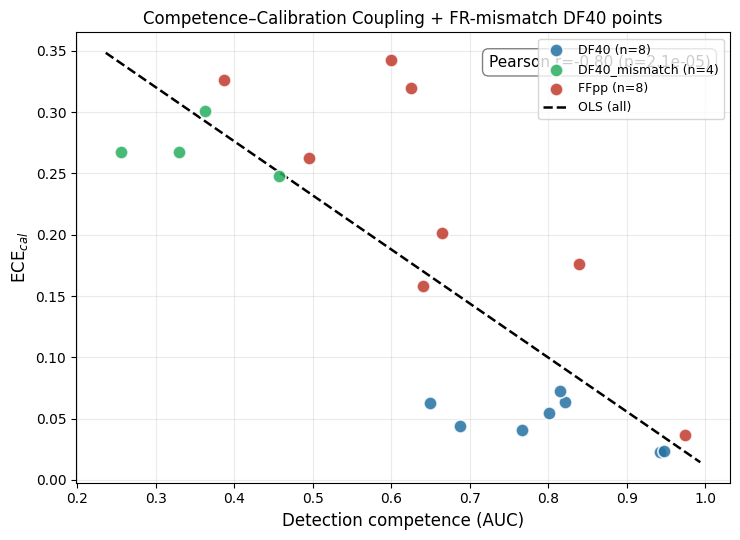

saved: /content/drive/MyDrive/CDTS_Research/deepfake-trust-research/figures/coupling_with_FRmismatch.png


In [5]:
import pandas as pd, numpy as np, os, glob
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"

# load all coupling sources
prev = pd.read_csv(f"{REPO}/reports/calibration/coupling_all_16pts.csv")[["AUC","ECE_cal","source"]]
frpt = pd.read_csv(f"{REPO}/reports/calibration/coupling_df40_FRmismatch.csv")[["AUC","ECE_cal","source"]]
allp = pd.concat([prev, frpt]).reset_index(drop=True)

# within-DF40 only (original FS-DF40 + new FR-DF40): does coupling appear now?
df40_all = allp[allp.source.str.startswith("DF40")]
if len(df40_all) > 3 and df40_all.AUC.nunique() > 2:
    r, p = pearsonr(df40_all.AUC, df40_all.ECE_cal)
    print(f"WITHIN-DF40 coupling now ({len(df40_all)} pts): Pearson r={r:.3f} (p={p:.4f})")

# full picture
rA, pA = pearsonr(allp.AUC, allp.ECE_cal)
print(f"FULL ({len(allp)} pts): Pearson r={rA:.3f} (p={pA:.4f})")

# figure
fig, ax = plt.subplots(figsize=(7.5,5.5))
colmap = {"FFpp":"#C0392B","DF40":"#2471A3","DF40_mismatch":"#27AE60"}
for src,g in allp.groupby("source"):
    ax.scatter(g.AUC, g.ECE_cal, s=90, alpha=0.85, label=f"{src} (n={len(g)})",
               color=colmap.get(src,"gray"), edgecolor="white", linewidth=1.2, zorder=3)
x,y = allp.AUC.values, allp.ECE_cal.values
b,a = np.polyfit(x,y,1); xs=np.linspace(x.min()-.02,x.max()+.02,100)
ax.plot(xs, a+b*xs, "k--", lw=1.8, label="OLS (all)")
ax.annotate(f"Pearson r={rA:.2f} (p={pA:.1e})", xy=(.97,.95), xycoords="axes fraction",
            ha="right", va="top", fontsize=11, bbox=dict(boxstyle="round,pad=0.4",fc="white",ec="gray"))
ax.set_xlabel("Detection competence (AUC)", fontsize=12)
ax.set_ylabel("ECE$_{cal}$", fontsize=12)
ax.set_title("Competence–Calibration Coupling + FR-mismatch DF40 points", fontsize=12)
ax.legend(loc="upper right", fontsize=9); ax.grid(True, alpha=0.25)
plt.tight_layout()
out = f"{REPO}/figures/coupling_with_FRmismatch.png"
plt.savefig(out, dpi=300, bbox_inches="tight"); plt.show()
print("saved:", out)

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
import os, glob
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"

print("=== confound-breaker results on disk ===")
print("FR-DF40 scores:", [os.path.basename(f) for f in glob.glob(f"{REPO}/reports/scores/xceptionFR_df40_*.parquet")])
print("FR-mismatch coupling CSV:", os.path.exists(f"{REPO}/reports/calibration/coupling_df40_FRmismatch.csv"))
print("combined figure:", os.path.exists(f"{REPO}/figures/coupling_with_FRmismatch.png"))

# show the key result is preserved
import pandas as pd
if os.path.exists(f"{REPO}/reports/calibration/coupling_df40_FRmismatch.csv"):
    fr = pd.read_csv(f"{REPO}/reports/calibration/coupling_df40_FRmismatch.csv")
    print("\nFR-mismatch points preserved:")
    print(fr[["method","AUC","ECE_cal"]].to_string(index=False))

Mounted at /content/drive
=== confound-breaker results on disk ===
FR-DF40 scores: ['xceptionFR_df40_simswap.parquet', 'xceptionFR_df40_blendface.parquet', 'xceptionFR_df40_StyleGAN2.parquet', 'xceptionFR_df40_sd2.1.parquet']
FR-mismatch coupling CSV: True
combined figure: True

FR-mismatch points preserved:
          method      AUC  ECE_cal
df40FR_StyleGAN2 0.256128 0.267667
df40FR_blendface 0.456514 0.248057
    df40FR_sd2.1 0.329142 0.267667
  df40FR_simswap 0.362896 0.301215


In [2]:
import os, subprocess, json
from datetime import datetime
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
os.chdir(REPO)
for f in [".gitconfig",".git-credentials"]:
    if os.path.exists(f"/content/drive/MyDrive/CDTS_Research/{f}"):
        subprocess.run(f'cp "/content/drive/MyDrive/CDTS_Research/{f}" /root/{f}', shell=True)

fp = f"{REPO}/reports/calibration/NB02_findings.json"
findings = json.load(open(fp))
findings["confound_breaker_NB04"] = {
    "date": datetime.now().isoformat(),
    "method": "FR (reenactment) checkpoint on DF40 FS/EFS methods to force low competence",
    "fr_df40_points": {"StyleGAN2":{"AUC":0.256,"ECE_cal":0.268},"sd2.1":{"AUC":0.329,"ECE_cal":0.268},
                       "simswap":{"AUC":0.363,"ECE_cal":0.301},"blendface":{"AUC":0.457,"ECE_cal":0.248}},
    "within_df40_coupling": {"n":12,"pearson_r":-0.939,"pearson_p":"<0.0001",
                             "note":"was -0.585 n.s. with only FS-DF40; FR-mismatch points break the confound"},
    "full_coupling": {"n":20,"pearson_r":-0.802,"pearson_p":"<0.0001"},
    "verdict": "CONFOUND BROKEN. Competence-driven not dataset. 4/4 low-AUC DF40 points show high ECE_cal."
}
json.dump(findings, open(fp,"w"), indent=2)

subprocess.run("git add reports/scores/xceptionFR_df40_*.parquet reports/calibration/coupling_df40_FRmismatch.csv reports/calibration/NB02_findings.json figures/coupling_with_FRmismatch.png", shell=True)
r = subprocess.run("git status --short", shell=True, capture_output=True, text=True)
print("=== staged ===")
print(r.stdout)

=== staged ===
 m external/DeepfakeBench
A  figures/coupling_with_FRmismatch.png
 M notebooks/GBDF_download.ipynb
 M notebooks/NB03_df40_scaling.ipynb
M  reports/calibration/NB02_findings.json
A  reports/calibration/coupling_df40_FRmismatch.csv
A  reports/scores/xceptionFR_df40_StyleGAN2.parquet
A  reports/scores/xceptionFR_df40_blendface.parquet
A  reports/scores/xceptionFR_df40_sd2.1.parquet
A  reports/scores/xceptionFR_df40_simswap.parquet
?? notebooks/NB04_confound_breaker.ipynb



In [3]:
import os, subprocess
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
os.chdir(REPO)
# also stage the notebooks
subprocess.run("git add notebooks/NB04_confound_breaker.ipynb notebooks/NB03_df40_scaling.ipynb", shell=True)

r = subprocess.run('git commit -m "NB04 confound-breaker: FR-mismatch forces low competence on DF40; 4/4 low-AUC points show HIGH ECE_cal -> within-DF40 coupling r=-0.94, confound BROKEN, finding is competence-driven not dataset"', shell=True, capture_output=True, text=True)
print(r.stdout); print(r.stderr if r.stderr else "")
r2 = subprocess.run("git push origin main", shell=True, capture_output=True, text=True)
print(r2.stdout[-300:] if r2.stdout else ""); print(r2.stderr[-200:] if r2.stderr else "")
r3 = subprocess.run("git rev-parse HEAD", shell=True, capture_output=True, text=True)
print("commit:", r3.stdout.strip())

[main 647e796] NB04 confound-breaker: FR-mismatch forces low competence on DF40; 4/4 low-AUC points show HIGH ECE_cal -> within-DF40 coupling r=-0.94, confound BROKEN, finding is competence-driven not dataset
 9 files changed, 41 insertions(+), 1 deletion(-)
 create mode 100644 figures/coupling_with_FRmismatch.png
 create mode 100644 notebooks/NB04_confound_breaker.ipynb
 create mode 100644 reports/calibration/coupling_df40_FRmismatch.csv
 create mode 100644 reports/scores/xceptionFR_df40_StyleGAN2.parquet
 create mode 100644 reports/scores/xceptionFR_df40_blendface.parquet
 create mode 100644 reports/scores/xceptionFR_df40_sd2.1.parquet
 create mode 100644 reports/scores/xceptionFR_df40_simswap.parquet



To https://github.com/anasbiswas1/deepfake-trust-research.git
   f7dcbe2..647e796  main -> main

commit: 647e7960feb8e5018726de31c854b5e25827fc46


In [4]:
import os, subprocess
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
os.chdir(REPO)
# after uploading RESEARCH_LOG_coupling.md to repo root via file browser:
for f in [".gitconfig",".git-credentials"]:
    if os.path.exists(f"/content/drive/MyDrive/CDTS_Research/{f}"):
        subprocess.run(f'cp "/content/drive/MyDrive/CDTS_Research/{f}" /root/{f}', shell=True)
subprocess.run("git add RESEARCH_LOG_coupling.md", shell=True)
r = subprocess.run('git commit -m "Research log: NB04 confound-breaker resolved -- coupling is competence-driven (r=-0.94 within DF40); next is NB05 third backbone"', shell=True, capture_output=True, text=True)
print(r.stdout)
subprocess.run("git push origin main 2>&1 | tail -3", shell=True)

On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
  (commit or discard the untracked or modified content in submodules)
	modified:   external/DeepfakeBench (modified content, untracked content)
	modified:   notebooks/GBDF_download.ipynb
	modified:   notebooks/NB04_confound_breaker.ipynb

no changes added to commit (use "git add" and/or "git commit -a")



CompletedProcess(args='git push origin main 2>&1 | tail -3', returncode=0)

In [5]:
import os, shutil, subprocess, glob
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
os.chdir(REPO)

old = f"{REPO}/RESEARCH_LOG_coupling.md"
new = f"{REPO}/RESEARCH_LOG_coupling (1).md"

# verify which is which before acting
def has_nb04(p):
    return os.path.exists(p) and ("CONFOUND-BREAKER" in open(p).read() or "confound resolved" in open(p).read().lower())
print("old file has NB04:", has_nb04(old))
print("(1) file has NB04:", has_nb04(new))

if has_nb04(new):
    # overwrite canonical with the updated content, remove the duplicate
    shutil.copy(new, old)
    os.remove(new)
    print("\noverwrote RESEARCH_LOG_coupling.md with updated content; removed (1) duplicate")
    # confirm
    print("canonical now has NB04:", has_nb04(old))
    print("duplicate gone:", not os.path.exists(new))
else:
    print("\nunexpected — (1) doesn't have NB04 content; stopping to recheck")

old file has NB04: False
(1) file has NB04: True

overwrote RESEARCH_LOG_coupling.md with updated content; removed (1) duplicate
canonical now has NB04: True
duplicate gone: True


In [6]:
import os, subprocess
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
os.chdir(REPO)
for f in [".gitconfig",".git-credentials"]:
    if os.path.exists(f"/content/drive/MyDrive/CDTS_Research/{f}"):
        subprocess.run(f'cp "/content/drive/MyDrive/CDTS_Research/{f}" /root/{f}', shell=True)
subprocess.run("git add RESEARCH_LOG_coupling.md", shell=True)
r = subprocess.run('git commit -m "Update research log: NB04 confound-breaker resolved -- coupling competence-driven (within-DF40 r=-0.94); next NB05 third backbone"', shell=True, capture_output=True, text=True)
print(r.stdout); print(r.stderr if r.stderr else "")
subprocess.run("git push origin main 2>&1 | tail -3", shell=True)
r2 = subprocess.run("git rev-parse HEAD", shell=True, capture_output=True, text=True)
print("commit:", r2.stdout.strip())

[main d74d303] Update research log: NB04 confound-breaker resolved -- coupling competence-driven (within-DF40 r=-0.94); next NB05 third backbone
 1 file changed, 153 insertions(+)
 create mode 100644 RESEARCH_LOG_coupling.md


commit: d74d30377b2a3f1d55be7170352f3bb36f070218
